# Notebook 4. Comparative Evaluation: Probing Three SSL Families on UCR Time Series

![Status](https://img.shields.io/static/v1.svg?label=Status&message=Finished&color=green)

**Filled notebook:**
[![Open In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lstival/ssl_tutorial_sibgrapi2026/blob/main/notebooks/time_series/04_comparative_evaluation.ipynb)
**Pretrained checkpoints:**
[![GitHub Releases](https://img.shields.io/static/v1.svg?logo=github&label=Repo&message=Checkpoints&color=lightgrey)](https://github.com/lstival/ssl_tutorial_sibgrapi2026/releases)

**Tutorial:** SIBGRAPI 2026 -- *Self-Supervised Learning: Contrastive, Masking, and Distillation Methods*

---

Three mechanisms, one architecture, one corpus, one protocol. This notebook asks the question
the whole time series part has been building toward: **which pretext task produced the most useful
representation?**

The protocol is deliberately, exactly the remote sensing part's:

1. **Freeze** the encoder -- no gradients ever flow into it.
2. Extract one feature vector per series.
3. Fit a **multinomial logistic regression** on the labeled training features.
4. Report **accuracy** on the untouched test split.

Because the evaluation is identical across both parts, the remote-sensing and time-series tables
can be read side by side, and the differences between them are attributable to the modality
rather than to the yardstick.

We measure four things:

- **Full-label accuracy** on SwedishLeaf.
- **The few-label regime** -- accuracy with only $k$ labeled examples per class. This is where
  SSL earns its keep, and where the gap over a random encoder is widest.
- **Cross-dataset transfer** -- the same frozen encoders probed on eight other UCR datasets they
  were never tuned for.
- **Reference points** -- a random-init floor, the classical 1-NN Euclidean baseline, and a
  supervised from-scratch ceiling.

In [1]:
## Standard libraries
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
import json
import math

## Imports for plotting
import matplotlib.pyplot as plt
import numpy as np

## PyTorch
import torch
import torch.nn as nn
import torch.utils.data as data

%matplotlib inline

In [2]:
# Make the shared tutorial module importable.
import os, sys, urllib.request

_LOCAL_SRC = os.path.join("..", "..", "src", "time_series")
if os.path.isfile(os.path.join(_LOCAL_SRC, "tutorial_ts.py")):
    sys.path.insert(0, _LOCAL_SRC)
elif not os.path.isfile("tutorial_ts.py"):
    urllib.request.urlretrieve("https://raw.githubusercontent.com/lstival/ssl_tutorial_sibgrapi2026/main/src/time_series/tutorial_ts.py", "tutorial_ts.py")

from tutorial_ts import (
    seed_everything, get_device, setup_plotting, check_colab_gpu, stage_ucr_locally,
    TARGET_DATASET, SERIES_LEN,
    UCRDataset, ucr_class_names,
    build_ts_encoder, try_load_checkpoint,
    extract_features, linear_probe_accuracy, subsample_per_class,
    plot_embedding_scatter,
)

setup_plotting()
seed_everything(42)
device = get_device()
print("Device:", device)
check_colab_gpu(device)

DATA_PATH = "../../data"
CHECKPOINT_PATH = "../../artifacts/time_series/checkpoints"

# On Colab, each notebook opened via File > Open notebook > GitHub gets its own fresh VM: a
# checkpoint saved -- or dataset downloaded -- by this notebook is invisible to another
# notebook opened separately, only to cells further down in *this* notebook. Mounting Drive
# repoints both paths at a folder that survives across notebooks and across sessions, so e.g.
# a checkpoint trained live here is still there when 04_comparative_evaluation runs later, and
# the dataset download only happens once across the whole tutorial. The dataset itself is
# read from the VM's local disk (Drive only keeps a compact ~25 MB cache of the UCR series the
# notebooks use, so the ~316 MB archive is downloaded and unpacked only once).
# Flip USE_DRIVE_FOR_TUTORIAL_DATA to False to keep everything local to this VM instead (e.g.
# to skip the Drive permission prompt, at the cost of losing state between notebooks).
USE_DRIVE_FOR_TUTORIAL_DATA = True
if USE_DRIVE_FOR_TUTORIAL_DATA and "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive")
    _drive_root = "/content/drive/MyDrive/ssl_tutorial_sibgrapi2026/time_series"
    CHECKPOINT_PATH = _drive_root + "/checkpoints"
    DATA_PATH = stage_ucr_locally("/content/data", _drive_root + "/data")
    os.makedirs(CHECKPOINT_PATH, exist_ok=True)
FIGURE_PATH = "figures"
os.makedirs(FIGURE_PATH, exist_ok=True)

# Colab (Linux) can run the augmentations in background worker processes, which keeps the GPU
# fed; local runs keep the single-process loading the notebooks were tuned with.
NUM_WORKERS = min(4, os.cpu_count() or 1) if "google.colab" in sys.modules else 0

Device: cuda:0


<Figure size 640x480 with 0 Axes>

In [3]:
# --- Check that the pretrained encoders are reachable -------------------------------
# Weights are published on a GitHub Release. Locally they are already on disk once fetched; on Colab they
# are downloaded on demand. This cell just reports what is available, so a missing or
# mis-served checkpoint shows up here rather than halfway through training below.
import os, urllib.request, urllib.error

_CKPTS = ["contrastive_ts_encoder.pt", "mae_ts_encoder.pt", "dino_ts_encoder.pt"]
_REPO = "lstival/ssl_tutorial_sibgrapi2026"
_MEDIA = f"https://github.com/{_REPO}/releases/download/weights-v1/"

for _name in _CKPTS:
    _local = os.path.join(CHECKPOINT_PATH, _name)
    _repo_copy = os.path.join("..", "..", "artifacts", "time_series", "checkpoints", _name)
    _found = next((p for p in (_local, _repo_copy) if os.path.isfile(p)), None)
    if _found and os.path.getsize(_found) > 1024:
        print(f"  on disk    {_name:<26} {os.path.getsize(_found)/1048576:.1f} MB")
        continue
    try:
        _req = urllib.request.Request(_MEDIA + _name, method="HEAD")
        with urllib.request.urlopen(_req, timeout=20) as _r:
            _mb = int(_r.headers.get("Content-Length") or 0) / 1048576
        print(f"  downloadable {_name:<24} {_mb:.1f} MB")
    except Exception as _e:
        print(f"  UNAVAILABLE  {_name:<24} {_e} -> this notebook will train live instead")


  downloadable contrastive_ts_encoder.pt 2.3 MB


  downloadable mae_ts_encoder.pt        2.3 MB


  downloadable dino_ts_encoder.pt       2.3 MB


## Data and the three pretrained encoders

Each mechanism is probed with the readout its objective actually trains. Contrastive and DINO
supervise the `[CLS]` token directly, so they are read with `pool="cls"`. MAE's loss lives
entirely on the patch tokens and never touches `[CLS]`, so it is read with `pool="mean"` --
the same asymmetry the remote sensing part documents for image MAE, and the reason `forward_features` takes a
`pool` argument.

In [4]:
train_ds = UCRDataset(DATA_PATH, TARGET_DATASET, "train")
test_ds  = UCRDataset(DATA_PATH, TARGET_DATASET, "test")
class_names = ucr_class_names(DATA_PATH, TARGET_DATASET)
n_classes = train_ds.n_classes

print(f"{TARGET_DATASET}: {len(train_ds)} train / {len(test_ds)} test, "
      f"{n_classes} classes, length {SERIES_LEN}")
print(f"chance accuracy = {1/n_classes:.4f}")

# mechanism -> (checkpoint file, readout)
CHECKPOINT_FILES = {
    "contrastive": ("contrastive_ts_encoder.pt", "cls"),
    "mae":         ("mae_ts_encoder.pt",         "mean"),
    "dino":        ("dino_ts_encoder.pt",        "cls"),
}

encoders, pools = {}, {}
for family, (fname, pool) in CHECKPOINT_FILES.items():
    enc = build_ts_encoder().to(device)
    if try_load_checkpoint(enc, CHECKPOINT_PATH, fname, device):
        enc.eval()
        for p in enc.parameters():
            p.requires_grad = False
        encoders[family] = enc
        pools[family] = pool
print("\nloaded:", list(encoders))

SwedishLeaf: 500 train / 625 test, 15 classes, length 128
chance accuracy = 0.0667


../../artifacts/time_series/checkpoints\contrastive_ts_encoder.pt is a Git LFS pointer, not the weights. Re-downloading...
Found pretrained model at ../../artifacts/time_series/checkpoints\contrastive_ts_encoder.pt, loading...


C:\WUR\tutorial_test\ssl_tutorial_sibgrapi2026\notebooks\time_series\..\..\src\time_series\tutorial_ts.py:1188: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = to

../../artifacts/time_series/checkpoints\mae_ts_encoder.pt is a Git LFS pointer, not the weights. Re-downloading...
Found pretrained model at ../../artifacts/time_series/checkpoints\mae_ts_encoder.pt, loading...


../../artifacts/time_series/checkpoints\dino_ts_encoder.pt is a Git LFS pointer, not the weights. Re-downloading...
Found pretrained model at ../../artifacts/time_series/checkpoints\dino_ts_encoder.pt, loading...

loaded: ['contrastive', 'mae', 'dino']


## Feature extraction and the full-label probe

Features are extracted **once** per encoder and reused for every probe below -- the full-label
fit, the few-label sweep and the t-SNE all read the same frozen vectors. That is what makes the
comparison cheap and, more importantly, exactly consistent.

In [5]:
# Measure BOTH readouts for every family before committing to one, so the choice below is
# reported rather than assumed.
readout = {}
for family, enc in encoders.items():
    readout[family] = {}
    for pl in ("cls", "mean"):
        a_tr, a_try = extract_features(enc, train_ds, device, pool=pl)
        a_te, a_tey = extract_features(enc, test_ds,  device, pool=pl)
        readout[family][pl] = linear_probe_accuracy(a_tr, a_try, a_te, a_tey)

print(f"{'family':>12s}  {'cls':>7s}  {'mean':>7s}   better")
for family, r in readout.items():
    print(f"{family:>12s}  {r['cls']:7.4f}  {r['mean']:7.4f}   "
          f"{max(r, key=r.get)}")

feats = {}
for family, enc in encoders.items():
    tr_f, tr_y = extract_features(enc, train_ds, device, pool=pools[family])
    te_f, te_y = extract_features(enc, test_ds,  device, pool=pools[family])
    feats[family] = (tr_f, tr_y, te_f, te_y)

# --- random-init floor: the same architecture, never trained ---
seed_everything(123)
rand_enc = build_ts_encoder().to(device).eval()
for p in rand_enc.parameters():
    p.requires_grad = False
r_tr, r_try = extract_features(rand_enc, train_ds, device, pool="cls")
r_te, r_tey = extract_features(rand_enc, test_ds,  device, pool="cls")
feats["random_init"] = (r_tr, r_try, r_te, r_tey)

# Keep the predictions alongside the accuracy: the confusion matrices further down need them,
# and re-fitting the probe just to recover them would be wasteful.
full_label, preds = {}, {}
for name, (tr_f, tr_y, te_f, te_y) in feats.items():
    full_label[name], preds[name] = linear_probe_accuracy(
        tr_f, tr_y, te_f, te_y, return_preds=True)
    print(f"{name:>12s}: {full_label[name]:.4f}")

      family      cls     mean   better
 contrastive   0.9104   0.9136   mean
         mae   0.8944   0.9024   mean
        dino   0.9392   0.9152   cls


 contrastive: 0.9104
         mae: 0.9024


        dino: 0.9392


 random_init: 0.8000


## Baselines: 1-NN Euclidean and supervised from scratch

Two reference points bracket the SSL results.

**1-NN with Euclidean distance** on the raw z-normalized series is the classical UCR baseline
that every paper on the archive quotes. It is not a straw man -- on many datasets it is
genuinely hard to beat, and it uses the labels directly rather than through a frozen
representation.

**Supervised from scratch** trains the same architecture end to end with labels. With only 500
labeled series a Transformer overfits quickly, which is precisely the condition SSL is meant to
address.

In [6]:
def nn_euclidean_accuracy(Xtr, ytr, Xte, yte):
    """1-NN Euclidean on raw z-normalized series: every test series takes the label of its
    nearest training series."""
    Xtr_t = torch.from_numpy(Xtr).to(device)
    Xte_t = torch.from_numpy(Xte).to(device)
    nearest = []
    for i in range(0, len(Xte_t), 256):
        d = torch.cdist(Xte_t[i:i + 256], Xtr_t)
        nearest.append(d.argmin(dim=1).cpu().numpy())
    return float((ytr[np.concatenate(nearest)] == yte).mean())


def supervised_end_to_end(train_set, test_set, n_out, epochs=60, lr=1e-3, weight_decay=1e-4,
                          batch_size=64, n_steps=None):
    """
    Same encoder, trained end to end with labels: the from-scratch baseline.

    Returns (accuracy, encoder, preds). The encoder and predictions come back so the
    supervised run can appear in the t-SNE panel and the confusion matrices next to the three
    SSL families, instead of being a lone number in a table.

    `n_steps` fixes the number of optimizer steps; by default it is `epochs` passes over
    `train_set`. The few-label and transfer sweeps below pass the full-label run's step count,
    so a model trained on 1 label per class gets the same optimization budget -- only the
    labels shrink, not the training.
    """
    seed_everything(42)
    enc = build_ts_encoder().to(device)
    head = nn.Linear(enc.embed_dim, n_out).to(device)
    loader = data.DataLoader(train_set, batch_size=batch_size, shuffle=True)
    if n_steps is None:
        n_steps = epochs * len(loader)
    opt = torch.optim.AdamW(list(enc.parameters()) + list(head.parameters()),
                            lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_steps)
    loss_fn = nn.CrossEntropyLoss()
    step = 0
    while step < n_steps:
        enc.train(); head.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = loss_fn(head(enc.forward_features(xb, pool="cls")), yb)
            opt.zero_grad(); loss.backward(); opt.step(); sched.step()
            step += 1
            if step == n_steps:
                break
    enc.eval(); head.eval()
    sup_preds, sup_true = [], []
    with torch.no_grad():
        for xb, yb in data.DataLoader(test_set, batch_size=256):
            logits = head(enc.forward_features(xb.to(device), pool="cls"))
            sup_preds.append(logits.argmax(1).cpu().numpy())
            sup_true.append(yb.numpy())
    sup_preds = np.concatenate(sup_preds)
    return float((sup_preds == np.concatenate(sup_true)).mean()), enc, sup_preds


# Optimizer steps of the full-label supervised run (60 epochs x 8 batches); every other
# supervised run in this notebook gets the same budget.
SUP_STEPS = 60 * math.ceil(len(train_ds) / 64)

nn_acc = nn_euclidean_accuracy(train_ds.X, train_ds.y, test_ds.X, test_ds.y)
sup_acc, sup_enc, sup_preds = supervised_end_to_end(train_ds, test_ds, n_classes)
print(f"1-NN Euclidean          : {nn_acc:.4f}")
print(f"supervised from scratch : {sup_acc:.4f}")

1-NN Euclidean          : 0.7888
supervised from scratch : 0.8736


## The few-label regime

This is the plot that matters most. A frozen SSL encoder plus a linear classifier needs very
few labels to work, because the representation was learned without any. We sweep $k$ labeled
examples per class and re-fit only the logistic regression each time -- the encoder never
changes.

In [7]:
LABEL_BUDGETS = [1, 2, 5, 10, 20]

few_label = {}
for name, (tr_f, tr_y, te_f, te_y) in feats.items():
    few_label[name] = {}
    for k in LABEL_BUDGETS:
        sub = subsample_per_class(tr_y, k)
        few_label[name][k] = linear_probe_accuracy(tr_f[sub], tr_y[sub], te_f, te_y)

# The two label-using baselines on exactly the same k-per-class subsets: 1-NN with only those
# k series as references, and the supervised model trained from scratch on them alone. Unlike
# the frozen SSL encoders, both see nothing but the k labeled series.
few_label["nn_euclidean"], few_label["supervised"] = {}, {}
for k in LABEL_BUDGETS:
    sub = subsample_per_class(train_ds.y, k)
    few_label["nn_euclidean"][k] = nn_euclidean_accuracy(
        train_ds.X[sub], train_ds.y[sub], test_ds.X, test_ds.y)
    few_label["supervised"][k] = supervised_end_to_end(
        data.Subset(train_ds, sub), test_ds, n_classes, n_steps=SUP_STEPS)[0]

full_with_baselines = {**full_label, "nn_euclidean": nn_acc, "supervised": sup_acc}
hdr = "  ".join(f"k={k:<4d}" for k in LABEL_BUDGETS)
print(f"{'method':>12s}  {hdr}   full")
for name in few_label:
    row = "  ".join(f"{few_label[name][k]:.3f} " for k in LABEL_BUDGETS)
    print(f"{name:>12s}  {row}  {full_with_baselines[name]:.3f}")

      method  k=1     k=2     k=5     k=10    k=20     full
 contrastive  0.578   0.730   0.816   0.874   0.886   0.910
         mae  0.483   0.579   0.715   0.827   0.862   0.902
        dino  0.590   0.746   0.850   0.885   0.930   0.939
 random_init  0.338   0.440   0.579   0.707   0.779   0.800
nn_euclidean  0.354   0.474   0.570   0.666   0.726   0.789
  supervised  0.374   0.461   0.635   0.746   0.843   0.874


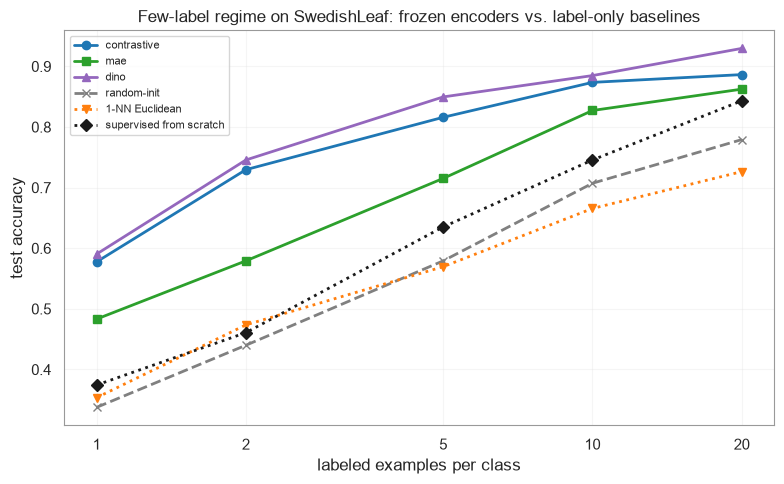

In [8]:
plt.figure(figsize=(8, 5))
styles = {"contrastive": ("tab:blue", "o"), "mae": ("tab:green", "s"),
          "dino": ("tab:purple", "^"), "random_init": ("0.5", "x"),
          "nn_euclidean": ("tab:orange", "v"), "supervised": ("k", "D")}
labels = {"random_init": "random-init", "nn_euclidean": "1-NN Euclidean",
          "supervised": "supervised from scratch"}
for name, curve in few_label.items():
    color, marker = styles.get(name, ("tab:red", "d"))
    ks = list(curve)
    plt.plot(ks, [curve[k] for k in ks], marker=marker, color=color,
             label=labels.get(name, name),
             linestyle=":" if name in ("nn_euclidean", "supervised")
             else "--" if name == "random_init" else "-")

plt.xscale("log"); plt.xticks(LABEL_BUDGETS, [str(k) for k in LABEL_BUDGETS])
plt.xlabel("labeled examples per class"); plt.ylabel("test accuracy")
plt.title(f"Few-label regime on {TARGET_DATASET}: frozen encoders vs. label-only baselines")
plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, "ts_few_label.png"), dpi=150)
plt.show(); plt.close()

## Cross-dataset transfer

Does the representation generalize, or did it merely memorize SwedishLeaf? We probe the same
frozen encoders on eight other UCR datasets spanning quite different domains -- ECG traces,
motion capture, other leaf and fish outlines, synthetic control charts -- with the same protocol
and no tuning of any kind.

In [9]:
TRANSFER_DATASETS = ["FaceAll", "ECG5000", "Trace", "Plane",
                     "SyntheticControl", "GunPoint", "OSULeaf", "Fish"]

# The frozen encoders, plus the two label-using baselines computed on each dataset's own
# labels (1-NN on its raw series, and a from-scratch model with the same step budget). The
# baselines involve no transfer at all -- they are the reference the transferred
# representations are measured against.
transfer = {name: {} for name in list(feats) + ["nn_euclidean", "supervised"]}
for ds_name in TRANSFER_DATASETS:
    tr_ds = UCRDataset(DATA_PATH, ds_name, "train")
    te_ds = UCRDataset(DATA_PATH, ds_name, "test")
    for name in feats:
        enc = rand_enc if name == "random_init" else encoders[name]
        pool = "cls" if name == "random_init" else pools[name]
        a_tr, a_try = extract_features(enc, tr_ds, device, pool=pool)
        a_te, a_tey = extract_features(enc, te_ds, device, pool=pool)
        transfer[name][ds_name] = linear_probe_accuracy(a_tr, a_try, a_te, a_tey)
    transfer["nn_euclidean"][ds_name] = nn_euclidean_accuracy(tr_ds.X, tr_ds.y, te_ds.X, te_ds.y)
    transfer["supervised"][ds_name] = supervised_end_to_end(
        tr_ds, te_ds, tr_ds.n_classes, n_steps=SUP_STEPS)[0]

print(f"{'dataset':>18s} " + " ".join(f"{n:>12s}" for n in transfer))
for ds_name in TRANSFER_DATASETS:
    print(f"{ds_name:>18s} " + " ".join(f"{transfer[n][ds_name]:12.3f}" for n in transfer))
print(f"{'MEAN':>18s} " + " ".join(
    f"{np.mean([transfer[n][d] for d in TRANSFER_DATASETS]):12.3f}" for n in transfer))

           dataset  contrastive          mae         dino  random_init nn_euclidean   supervised
           FaceAll        0.733        0.660        0.714        0.630        0.715        0.732
           ECG5000        0.938        0.930        0.938        0.933        0.924        0.933
             Trace        1.000        1.000        1.000        0.830        0.750        0.890
             Plane        1.000        0.990        0.990        0.971        0.962        0.943
  SyntheticControl        0.997        0.930        0.983        0.900        0.897        0.950
          GunPoint        0.987        0.980        0.973        0.880        0.913        0.900
           OSULeaf        0.740        0.657        0.748        0.541        0.512        0.558
              Fish        0.914        0.846        0.863        0.731        0.783        0.789
              MEAN        0.914        0.874        0.901        0.802        0.807        0.837


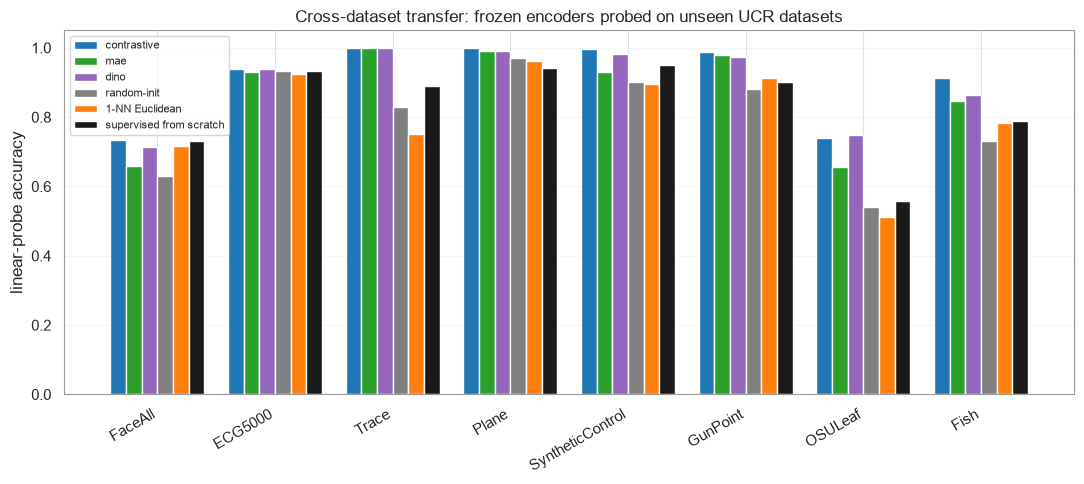

In [10]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(TRANSFER_DATASETS))
names = [n for n in ["contrastive", "mae", "dino", "random_init", "nn_euclidean",
                     "supervised"] if n in transfer]
width = 0.8 / len(names)
for i, name in enumerate(names):
    color = styles.get(name, ("tab:red", None))[0]
    ax.bar(x + i * width, [transfer[name][d] for d in TRANSFER_DATASETS],
           width, label=labels.get(name, name), color=color)
ax.set_xticks(x + width * (len(names) - 1) / 2)
ax.set_xticklabels(TRANSFER_DATASETS, rotation=30, ha="right")
ax.set_ylabel("linear-probe accuracy")
ax.set_title("Cross-dataset transfer: frozen encoders probed on unseen UCR datasets")
ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, "ts_transfer.png"), dpi=150)
plt.show(); plt.close()

In [11]:
# Fold the supervised-from-scratch run into the shared dicts so the three comparisons below
# cover all four training regimes, not just the three SSL ones.
#
# This happens here, after the few-label and cross-dataset sections, on purpose: those loops
# iterate `feats` and look each family up in `encoders`, where a supervised entry does not
# exist. Its encoder is also not comparable there -- it was trained *with* SwedishLeaf labels,
# so a few-label or transfer number for it would not mean the same thing as for a frozen SSL
# encoder.
for p_ in sup_enc.parameters():
    p_.requires_grad = False
sup_enc.eval()
s_tr, s_try = extract_features(sup_enc, train_ds, device, pool="cls")
s_te, s_tey = extract_features(sup_enc, test_ds,  device, pool="cls")
feats["supervised"] = (s_tr, s_try, s_te, s_tey)
full_label["supervised"] = sup_acc
preds["supervised"] = sup_preds
print("supervised features added:", s_te.shape)

supervised features added: (625, 128)


## Embedding geometry: t-SNE of the frozen features

The probe reports one number per encoder. It does not show *why* one encoder is easier to
separate than another. Projecting the same frozen test features to two dimensions does: a
representation that a linear head can read is one where the classes already sit in distinct
regions before any classifier is fitted.

The same three lines that notebooks 1 to 3 ran for a single mechanism, now run for all four
training regimes on identical features, so the panels are directly comparable.

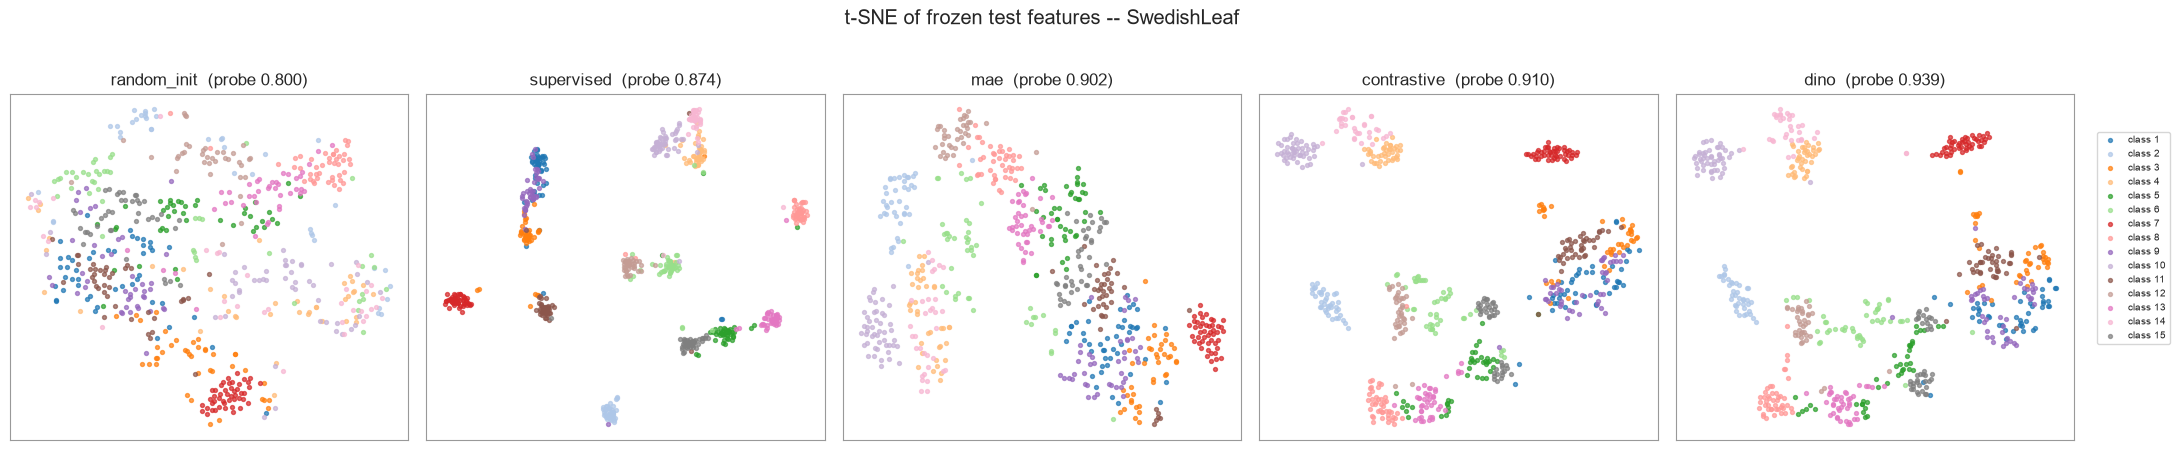

In [12]:
from sklearn.manifold import TSNE

# One panel per training regime, in a fixed order so the panels read left to right from the
# weakest to the strongest probe. Perplexity 30 and init="pca" match the mechanism notebooks.
TSNE_ORDER = [f for f in ["random_init", "supervised", "mae", "contrastive", "dino"]
              if f in feats]

fig, axes = plt.subplots(1, len(TSNE_ORDER), figsize=(4.2 * len(TSNE_ORDER), 4.4))
axes = np.atleast_1d(axes)

for ax, family in zip(axes, TSNE_ORDER):
    _, _, te_f, te_y = feats[family]
    emb = TSNE(n_components=2, random_state=42, init="pca", perplexity=30).fit_transform(te_f)
    # legend=False on every panel: 15 SwedishLeaf classes repeated five times would cover the
    # figure. One shared legend is added below instead.
    plot_embedding_scatter(emb, te_y, class_names=class_names, ax=ax, legend=False,
                           title=f"{family}  (probe {full_label[family]:.3f})")
    ax.set_xticks([]); ax.set_yticks([])

# Single shared legend, taken from the last panel's handles since all panels share the classes.
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=7)
fig.suptitle(f"t-SNE of frozen test features -- {TARGET_DATASET}", y=1.02)
plt.tight_layout()
plt.show()
plt.close()

<div class="alert alert-info">

Read the panels against the probe numbers in their titles. The random-init panel is the
control: even untrained features carry *some* class structure on short z-normalized series,
which is why it is a genuinely strong floor rather than a formality. The pretrained panels
should show tighter, better-separated groups, and the ordering of visual separation should
track the probe accuracies.

</div>

## Summary bar chart: full-label accuracy by training regime

The same chart the remote sensing comparative evaluation ends on, so the two tracks' results
can be laid side by side. The classical 1-NN Euclidean baseline is included because it is the
number the UCR literature has reported for two decades.

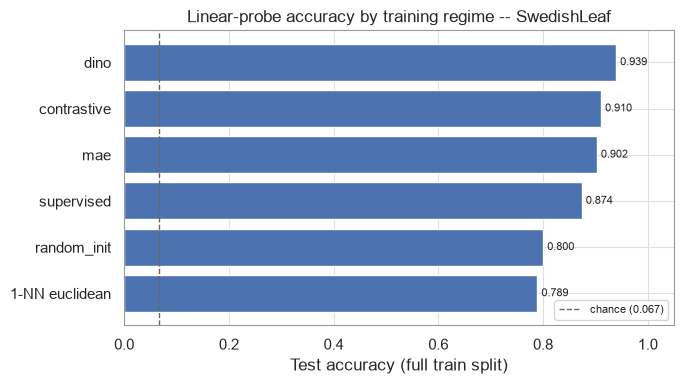

In [13]:
bar_results = dict(full_label)
bar_results["1-NN euclidean"] = nn_acc

families_sorted = sorted(bar_results, key=lambda k: bar_results[k])
plt.figure(figsize=(7, 4))
bars = plt.barh(families_sorted, [bar_results[f] for f in families_sorted])

# Mark chance so the whole range is interpretable: with 15 classes chance is 0.067, far below
# every bar, which is the point worth seeing.
plt.axvline(1 / n_classes, color="0.4", linestyle="--", linewidth=1,
            label=f"chance ({1/n_classes:.3f})")
for bar, family in zip(bars, families_sorted):
    plt.text(bar.get_width() + 0.008, bar.get_y() + bar.get_height() / 2,
             f"{bar_results[family]:.3f}", va="center", fontsize=8)

plt.xlim(0, 1.05)
plt.xlabel("Test accuracy (full train split)")
plt.title(f"Linear-probe accuracy by training regime -- {TARGET_DATASET}")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()
plt.close()

## Confusion matrices

Accuracy hides *which* classes an encoder confuses. Normalizing each row shows, for every true
class, where its test series actually landed: a good encoder has a bright diagonal, and the
off-diagonal mass tells you which leaf species this representation treats as the same thing.

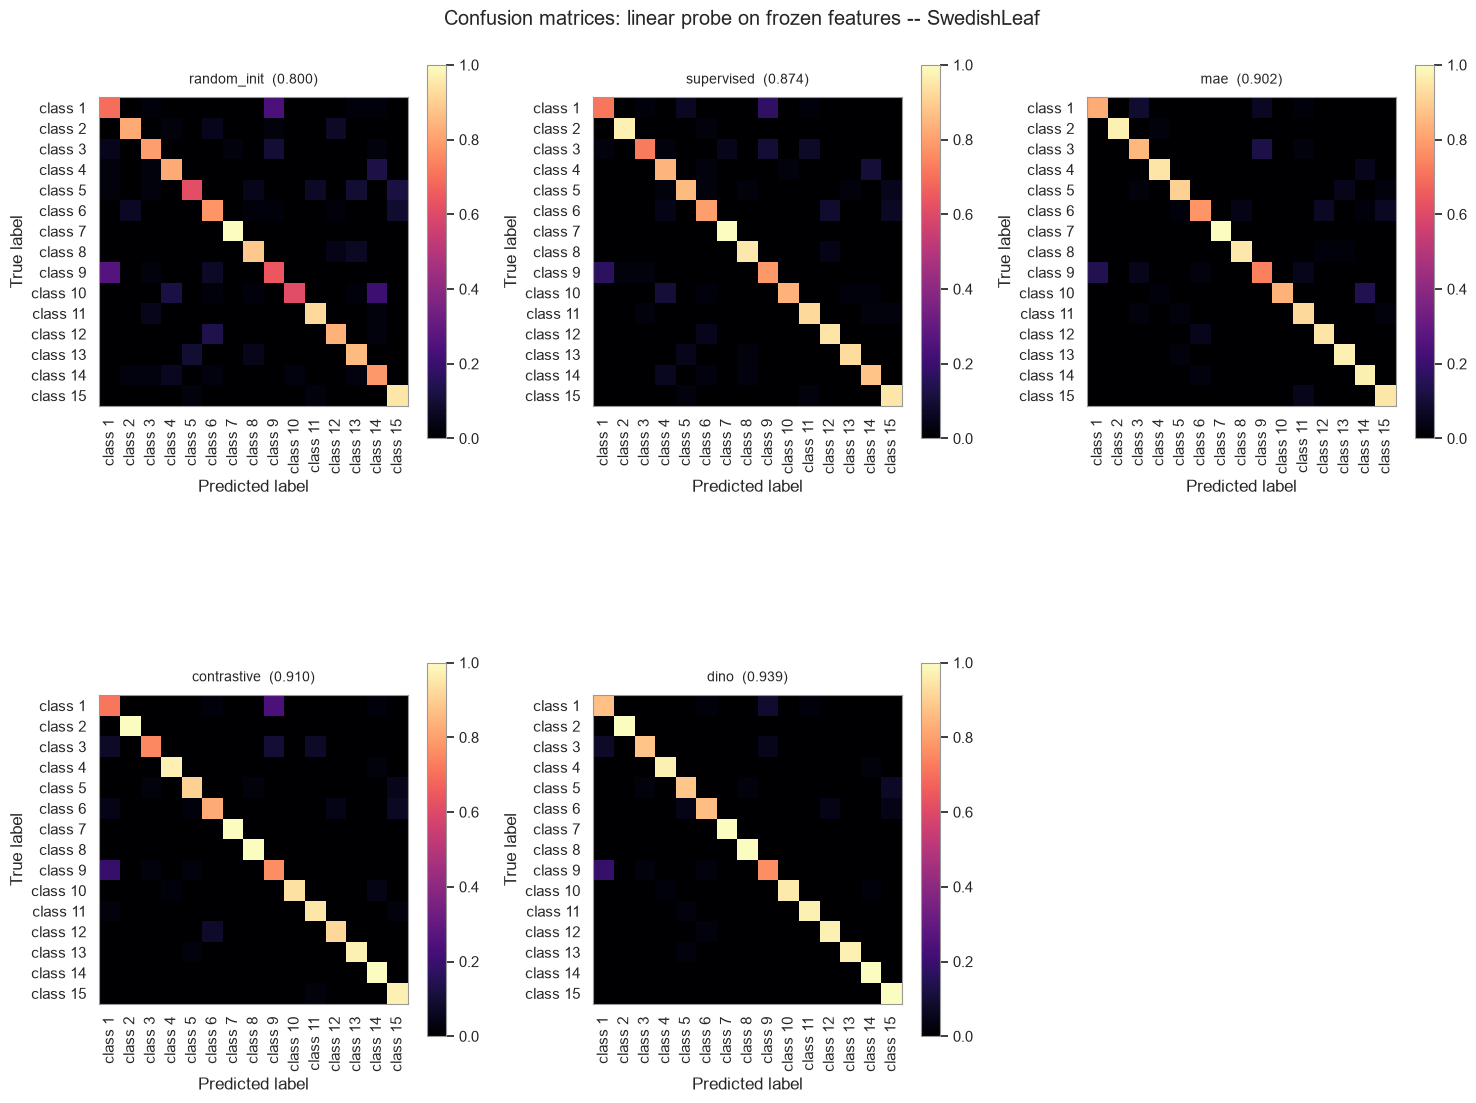

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay

# 3-column grid so the matrices sit close enough to compare at a glance rather than one
# full-size figure per regime.
cm_order = TSNE_ORDER
n_cols = 3
n_rows = math.ceil(len(cm_order) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5.5 * n_rows))
axes = np.atleast_1d(axes).flatten()

for ax, family in zip(axes, cm_order):
    # include_values=False: with 15 SwedishLeaf classes the 225 per-cell numbers overlap
    # illegibly at this subplot size; the colormap carries the value instead.
    ConfusionMatrixDisplay.from_predictions(
        feats[family][3], preds[family],
        display_labels=class_names, normalize="true",
        cmap="magma", xticks_rotation=90, include_values=False, colorbar=True, ax=ax,
    )
    ax.grid(False)
    ax.set_title(f"{family}  ({full_label[family]:.3f})", fontsize=10, pad=10)

for ax in axes[len(cm_order):]:
    ax.set_visible(False)

fig.suptitle(f"Confusion matrices: linear probe on frozen features -- {TARGET_DATASET}")
plt.tight_layout()
fig.subplots_adjust(hspace=0.6, top=0.93)
plt.show()
plt.close()

## Summary table

In [15]:
results = {
    "target": TARGET_DATASET,
    "series_len": SERIES_LEN,
    "n_classes": n_classes,
    "n_train": len(train_ds),
    "n_test": len(test_ds),
    "label_budgets": LABEL_BUDGETS,
    "full_label": {k: float(v) for k, v in full_label.items()},
    "readout": {f: {p: float(v) for p, v in r.items()} for f, r in readout.items()},
    "pools_used": dict(pools),
    "few_label": {n: {str(k): float(v) for k, v in c.items()} for n, c in few_label.items()},
    "transfer": {n: {d: float(v) for d, v in c.items()} for n, c in transfer.items()},
    "nn_euclidean": float(nn_acc),
    "supervised": float(sup_acc),
}
with open(os.path.join(FIGURE_PATH, "ts_eval_results.json"), "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2)

# Chance does not depend on k; across the transfer sets it is the mean of 1 / n_classes.
transfer_chance = np.mean([1 / UCRDataset(DATA_PATH, d, "train").n_classes
                           for d in TRANSFER_DATASETS])
rows = [("contrastive", "contrastive"), ("dino", "dino"), ("mae", "mae"),
        ("random_init", "random-init"), None,
        ("nn_euclidean", "1-NN Euclidean"), ("supervised", "supervised (scratch)")]
print(f"{'method':>22s}   {'full':>7s}  {'k=1':>7s}  {'k=5':>7s}  {'transfer avg':>12s}")
print("-" * 65)
for row in rows:
    if row is None:
        print("-" * 65)
        continue
    n, label = row
    if n not in full_with_baselines:
        continue
    tavg = np.mean([transfer[n][d] for d in TRANSFER_DATASETS])
    print(f"{label:>22s}   {full_with_baselines[n]:7.4f}  {few_label[n][1]:7.4f}  "
          f"{few_label[n][5]:7.4f}  {tavg:12.4f}")
print(f"{'chance':>22s}   {1/n_classes:7.4f}  {1/n_classes:7.4f}  {1/n_classes:7.4f}  "
      f"{transfer_chance:12.4f}")

                method      full      k=1      k=5  transfer avg
-----------------------------------------------------------------
           contrastive    0.9104   0.5776   0.8160        0.9136
                  dino    0.9392   0.5904   0.8496        0.9012
                   mae    0.9024   0.4832   0.7152        0.8741
           random-init    0.8000   0.3376   0.5792        0.8021
-----------------------------------------------------------------
        1-NN Euclidean    0.7888   0.3536   0.5696        0.8071
  supervised (scratch)    0.8736   0.3744   0.6352        0.8367
                chance    0.0667   0.0667   0.0667        0.2051


## Discussion

<div class="alert alert-info">

**Results from a real run of this notebook** (fixed UCR TRAIN/TEST split, seed 42; encoders
pretrained 15k steps on the pooled 128-dataset UCR corpus of 45,192 series).
Your numbers will vary a little with the pretraining budget.
The two label-using baselines see only the labeled series of each column: at k=1 the
supervised model is trained from scratch on 15 series (with the same 480 optimizer steps as
the full-label run) and 1-NN has 15 references. In the transfer column both are fitted on
each dataset's own labels, so they involve no transfer at all. Chance is 1/15 on
SwedishLeaf and the mean of 1/n_classes over the eight transfer datasets.

| method | full-label acc | k=1 / class | k=5 / class | transfer avg (8 datasets) |
|---|---|---|---|---|
| **DINO** (`[CLS]`) | **0.939** | 0.590 | 0.850 | 0.901 |
| contrastive (`[CLS]` 0.910, mean 0.914) | 0.910 | 0.578 | 0.816 | **0.914** |
| MAE (`[CLS]` 0.898, mean 0.902) | 0.902 | 0.483 | 0.715 | 0.874 |
| random-init encoder | 0.800 | 0.338 | 0.579 | 0.802 |
| supervised, from scratch | 0.874 | 0.374 | 0.635 | 0.837 |
| 1-NN Euclidean (classical UCR baseline) | 0.789 | 0.354 | 0.570 | 0.807 |
| chance | 0.067 | 0.067 | 0.067 | 0.205 |

Read the numbered points below against this table.

**1. The random-init floor is high, and that is the point.** An untrained Transformer followed
by a logistic regression is a *random features* model, and random features are a genuinely
strong baseline on short, z-normalized series, here 0.800, already above the 0.789 of 1-NN
Euclidean. Any evaluation that omits this floor overstates what SSL contributed. The honest
gain from each pretext task is its distance *above* 0.800: DINO +0.139, contrastive
+0.110, MAE +0.102. All three clear it, and all three also clear
**supervised-from-scratch** (0.874): a 500-label Transformer overfits, and a frozen pretrained
encoder plus a linear head does not.

**2. The few-label regime is where SSL pays.** At the full 500-label budget the methods sit in
a fairly narrow band. Drop to one label per class and they separate sharply: DINO and
contrastive hold about 0.590 and 0.578 while random-init collapses to 0.338 -- and so do
the label-only baselines: the from-scratch Transformer reaches 0.374 and 1-NN 0.354. At
k=5 the gap is still wide (DINO 0.850 against 0.635 supervised). This is the
same shape of result the remote sensing part found on EuroSAT, and it is the honest answer to
"when should I bother with SSL?": when labels are scarce.

**3. The readout is part of the method.** The table at the top of this notebook probes every
encoder through *both* `[CLS]` and mean-pooled patch tokens, and the two disagree. The textbook
expectation (He et al. 2022) is that MAE, whose loss never touches `[CLS]`, should read out
better from mean-pooled patch tokens, while contrastive and DINO, which train `[CLS]` directly,
should prefer it. MAE and DINO both follow that story here: MAE reads better from mean-pool
(0.902 against 0.898) and DINO clearly prefers `[CLS]` (0.939 against 0.915). Contrastive is
the exception, reading marginally better from mean-pool (0.914) than from `[CLS]`
(0.910), a gap small enough to be run-to-run noise. Note also how much the size of the
gap varies: DINO's readout choice is worth 0.024 accuracy, contrastive's about
0.003. The lesson is not which readout "wins" but that you must report the one you used
rather than quietly picking the better number. An evaluation that fixes one readout for all
methods is comparing methods-plus-a-readout-choice, not methods.

**4. Transfer separates representation from memorization.** The cross-dataset panel probes the
same frozen encoders on ECG traces, control charts, gestures and other outlines, domains
sharing nothing with SwedishLeaf but the fact of being a sequence. Every SSL encoder's transfer
average (0.874 to 0.914) sits above random-init's (0.802), and accuracy there cannot come
from having memorized SwedishLeaf. It also sits above the baselines that are *fitted on
each transfer dataset's own labels*: 1-NN (0.807) and a from-scratch Transformer (0.837).
A frozen encoder that never saw these datasets, read by a linear head, beats a model of the
same architecture trained end to end on them. It is the cleanest available evidence that the pretext tasks
learned something about *sequences* rather than about leaf outlines. Worth noticing: contrastive
transfers best even though DINO probes best on the target, so "which encoder is better" depends
on whether you are asking about this dataset or about sequences in general.

**5. What carried over from the remote sensing part, and what did not.** The mechanisms
transferred essentially unchanged. The InfoNCE, masking and DINO cells are the same code in
both parts, and the result shape is the same: SSL beats a random-features floor, beats
supervised-from-scratch in the low-label regime, and self-distillation edges ahead. What did
*not* transfer were the hyperparameters that depend on token budget and on which nuisances are
real: the MAE mask ratio dropped from 0.75 to 0.5 because a 128-step series yields 8 patch
tokens rather than 64, and the augmentation recipe had to *forbid* the flips that were free on
nadir imagery, because a reversed or sign-flipped series is often a different class outright.

That is the generalizable lesson of the two parts together. The **mechanism** is portable; the
**invariances and the token budget** are properties of the modality, and they are what you
must re-derive each time.

### References

- Dau, H. A. et al. (2019). *The UCR Time Series Archive.* IEEE/CAA J. Autom. Sinica.
- Chen, T. et al. (2020). *SimCLR.* ICML.
- He, K. et al. (2022). *Masked Autoencoders Are Scalable Vision Learners.* CVPR.
- Caron, M. et al. (2021). *Emerging Properties in Self-Supervised Vision Transformers (DINO).*
  ICCV.
- Yue, Z. et al. (2022). *TS2Vec.* AAAI.
- Nie, Y. et al. (2023). *PatchTST.* ICLR.
- Stival, L. et al. (2025/2026). *[Tutorial paper: full citation TBD].*
